In [45]:
import pandas as pd
import numpy as np

In [46]:
data = 'https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv'

In [47]:
!wget $data 

--2025-10-06 15:59:05--  https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 874188 (854K) [text/plain]
Saving to: ‘car_fuel_efficiency.csv.5’

car_fuel_efficiency 100%[===================>] 853.70K  --.-KB/s    in 0.008s  

2025-10-06 15:59:05 (102 MB/s) - ‘car_fuel_efficiency.csv.5’ saved [874188/874188]



In [48]:
df = pd.read_csv('car_fuel_efficiency.csv')

In [49]:
base = ['engine_displacement',
'horsepower',
'vehicle_weight',
'model_year',
'fuel_efficiency_mpg']
df_base = df[base]
df_base

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,170,159.0,3413.433759,2003,13.231729
1,130,97.0,3149.664934,2007,13.688217
2,170,78.0,3079.038997,2018,14.246341
3,220,NaN,2542.392402,2009,16.912736
4,210,140.0,3460.870990,2009,12.488369
...,...,...,...,...,...
9699,140,164.0,2981.107371,2013,15.101802
9700,180,154.0,2439.525729,2004,17.962326
9701,220,138.0,2583.471318,2008,17.186587
9702,230,177.0,2905.527390,2011,15.331551


In [50]:
df_base.dtypes

engine_displacement      int64
horsepower             float64
vehicle_weight         float64
model_year               int64
fuel_efficiency_mpg    float64
dtype: object

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

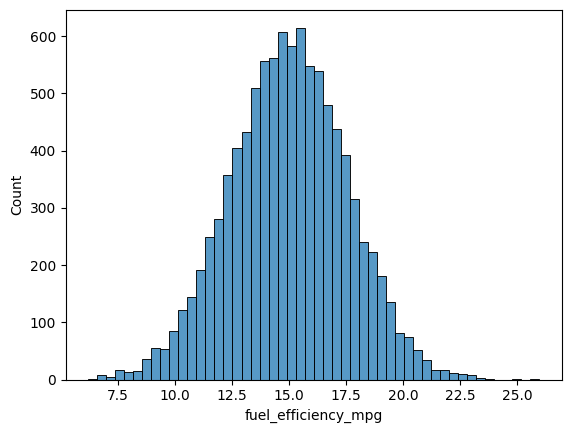

In [52]:
sns.histplot(df_base.fuel_efficiency_mpg, bins=50)

In [53]:
df_base.isnull().sum()

engine_displacement      0
horsepower             708
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

In [54]:
median_horsepower = df_base['horsepower'].median()
median_horsepower

np.float64(149.0)

In [55]:
n = len(df_base)

n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

In [56]:
n

9704

In [57]:
n_val, n_test, n_train

(1940, 1940, 5824)

In [58]:
df_train = df_base.iloc[:n_train]
df_val = df_base.iloc[n_train:n_train+n_val]
df_test = df_base.iloc[n_train+n_val:]

In [59]:
idx = np.arange(n)
np.random.seed(42)
np.random.shuffle(idx)

In [60]:
df_train = df_base.iloc[idx[:n_train]]
df_val = df_base.iloc[idx[n_train:n_train+n_val]]
df_test = df_base.iloc[idx[n_train+n_val:]]

In [61]:
df_train.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
483,220,144.0,2535.887591,2009,16.642943
7506,160,141.0,2741.170484,2019,16.298377
8795,230,155.0,2471.880237,2017,18.591822
1688,150,206.0,3748.164469,2015,11.818843
6217,300,111.0,2135.716359,2006,19.402209


In [62]:
len(df_train), len(df_val), len(df_test)

(5824, 1940, 1940)

In [63]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [64]:
df_train.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,220,144.0,2535.887591,2009,16.642943
1,160,141.0,2741.170484,2019,16.298377
2,230,155.0,2471.880237,2017,18.591822
3,150,206.0,3748.164469,2015,11.818843
4,300,111.0,2135.716359,2006,19.402209


In [65]:
y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

<Axes: ylabel='Count'>

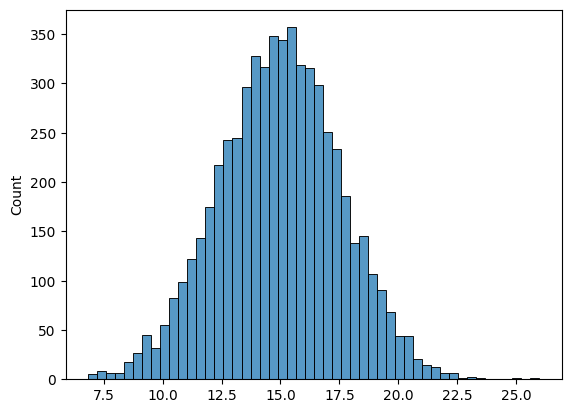

In [66]:
sns.histplot(y_train, bins=50)

In [67]:
len(y_train)

5824

In [68]:
del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

In [69]:
df_train.head()

,engine_displacement,horsepower,vehicle_weight,model_year
0,220,144.0,2535.887591,2009
1,160,141.0,2741.170484,2019
2,230,155.0,2471.880237,2017
3,150,206.0,3748.164469,2015
4,300,111.0,2135.716359,2006


In [70]:
base = ['engine_displacement',
'horsepower',
'vehicle_weight',
'model_year']

In [71]:
def prepare_X0(df):
    df = df.copy()
    
    df_num = df[base]
    df_num = df_num.fillna(0)
    X = df_num.values

    return X

In [72]:
def prepare_X_mean(df):
    df = df.copy()
    
    df_num = df[base]
    mean_horsepower = df['horsepower'].mean()
    df_num['horsepower'] = df_num['horsepower'].fillna(mean_horsepower)
    X = df_num.values

    return X

In [73]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [74]:
def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [75]:
X_train_0 = prepare_X0(df_train)

In [76]:
w0_0, w_0 = train_linear_regression(X_train_0, y_train)
w0_0

np.float64(28.827365475106156)

In [77]:
w_0

array([ 9.93613218e-05,  3.54221891e-03, -5.01328015e-03,  3.42992869e-04])

In [78]:
X_train_m = prepare_X_mean(df_train)
w0_m, w_m = train_linear_regression(X_train_m, y_train)
w0_m

np.float64(28.925259952113596)

In [79]:
w_m

array([ 0.00012093,  0.01030308, -0.00501009, -0.00023463])

In [80]:
X_val_0 = prepare_X0(df_val)
y_pred_0 = w0_0 + X_val_0.dot(w_0)
rmse(y_val, y_pred_0).round(2)

np.float64(0.52)

In [81]:
X_val_m = prepare_X_mean(df_val)
y_pred_m = w0_m + X_val_m.dot(w_m)
rmse(y_val, y_pred_m).round(2)

np.float64(0.46)

In [82]:
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [83]:
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    X_train = prepare_X0(df_train)
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)

    X_val = prepare_X0(df_val)
    y_pred = w0 + X_val.dot(w)
    score = rmse(y_val, y_pred)
    
    print(r, score)

0 0.5173782638857467
0.01 0.5171115525767522
0.1 0.5187525130701821
1 0.5222348802092772
5 0.5228916092823478
10 0.5229812979636581
100 0.5230636233819926


In [84]:
seeds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
n_s = len(seeds)
n_s

10

In [85]:
scores = np.zeros(n_s)
scores

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [86]:
for p in range(n_s):
    df_train = df_base.iloc[:n_train]
    df_val = df_base.iloc[n_train:n_train+n_val]
    df_test = df_base.iloc[n_train+n_val:]

    idx = np.arange(n)
    np.random.seed(seeds[p])
    np.random.shuffle(idx)

    df_train = df_base.iloc[idx[:n_train]]
    df_val = df_base.iloc[idx[n_train:n_train+n_val]]
    df_test = df_base.iloc[idx[n_train+n_val:]]

    df_train = df_train.reset_index(drop=True)
    df_val = df_val.reset_index(drop=True)
    df_test = df_test.reset_index(drop=True)

    y_train = df_train.fuel_efficiency_mpg.values
    y_val = df_val.fuel_efficiency_mpg.values
    y_test = df_test.fuel_efficiency_mpg.values

    del df_train['fuel_efficiency_mpg']
    del df_val['fuel_efficiency_mpg']
    del df_test['fuel_efficiency_mpg']

    X_train = prepare_X0(df_train)
    w0, w = train_linear_regression(X_train, y_train)

    X_val = prepare_X0(df_val)
    y_pred = w0 + X_val.dot(w)
    scores[p] = rmse(y_val, y_pred)

    print(scores[p])

0.5206531296292951
0.5213388912860217
0.5228069974785726
0.5159516741108942
0.5109129460108117
0.5283406460133415
0.5313910658151165
0.5090670387365963
0.5147399129426932
0.5131865908408015


In [87]:
std_dev_scores = np.std(scores)
std_dev_scores

np.float64(0.006989446425721602)

In [89]:
df_train = df_base.iloc[:n_train]
df_val = df_base.iloc[n_train:n_train+n_val]
df_test = df_base.iloc[n_train+n_val:]

idx = np.arange(n)
np.random.seed(9)
np.random.shuffle(idx)

df_train = df_base.iloc[idx[:n_train]]
df_val = df_base.iloc[idx[n_train:n_train+n_val]]
df_test = df_base.iloc[idx[n_train+n_val:]]

df_test = df_test.reset_index(drop=True)

y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

del df_test['fuel_efficiency_mpg']

df_full_train = pd.concat([df_train, df_val])
df_full_train = df_full_train.reset_index(drop=True)
del df_full_train['fuel_efficiency_mpg']

X_full_train = prepare_X0(df_full_train)

y_full_train = np.concatenate([y_train, y_val])

w0, w = train_linear_regression_reg(X_full_train, y_full_train, r=0.001)

In [90]:
X_test = prepare_X0(df_test)
y_pred = w0 + X_test.dot(w)
score = rmse(y_test, y_pred)
score

np.float64(0.5156261299167999)